Generating t-SNE plot. This may take a moment depending on dataset size.


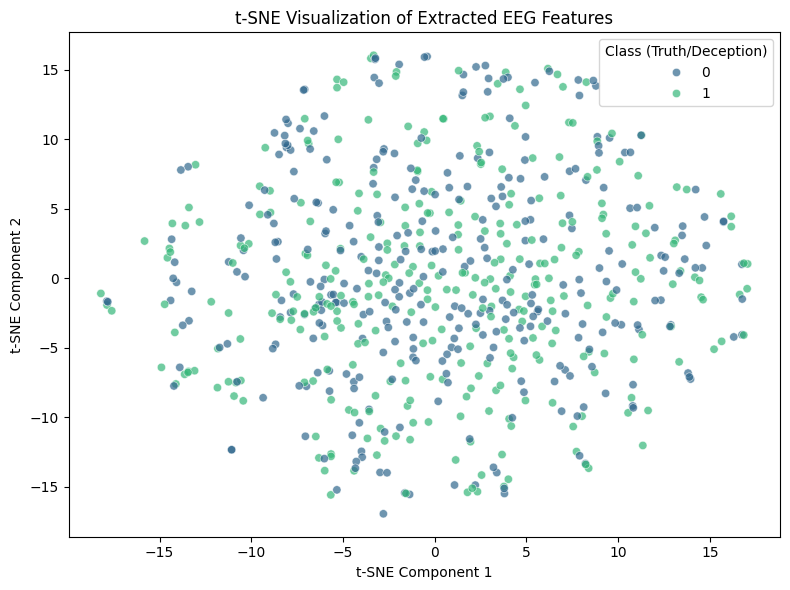

LSTM input shape: (662, 5, 1312)
Starting training...
Epoch 1/15 | Train Loss: 0.6942 | Val Loss: 0.6865
Epoch 2/15 | Train Loss: 0.6776 | Val Loss: 0.6798
Epoch 3/15 | Train Loss: 0.6539 | Val Loss: 0.6628
Epoch 4/15 | Train Loss: 0.6089 | Val Loss: 0.6187
Epoch 5/15 | Train Loss: 0.5078 | Val Loss: 0.5184
Epoch 6/15 | Train Loss: 0.3541 | Val Loss: 0.3561
Epoch 7/15 | Train Loss: 0.1745 | Val Loss: 0.2118
Epoch 8/15 | Train Loss: 0.0739 | Val Loss: 0.1353
Epoch 9/15 | Train Loss: 0.0556 | Val Loss: 0.1174
Epoch 10/15 | Train Loss: 0.0258 | Val Loss: 0.1091
Epoch 11/15 | Train Loss: 0.0157 | Val Loss: 0.1219
Epoch 12/15 | Train Loss: 0.0110 | Val Loss: 0.1143
Epoch 13/15 | Train Loss: 0.0060 | Val Loss: 0.1326
Epoch 14/15 | Train Loss: 0.0045 | Val Loss: 0.1294
Epoch 15/15 | Train Loss: 0.0031 | Val Loss: 0.1304

Accuracy: 0.9473684210526315

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.94      0.95        67
         1.

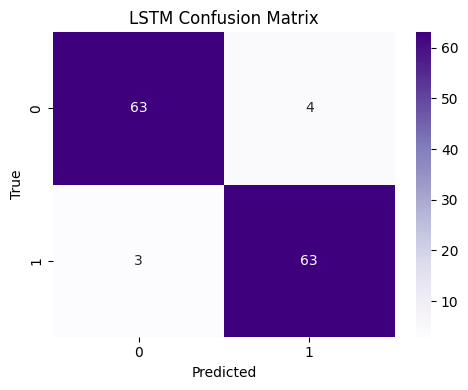

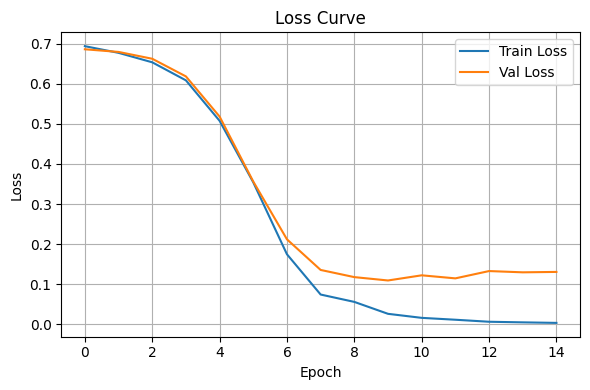

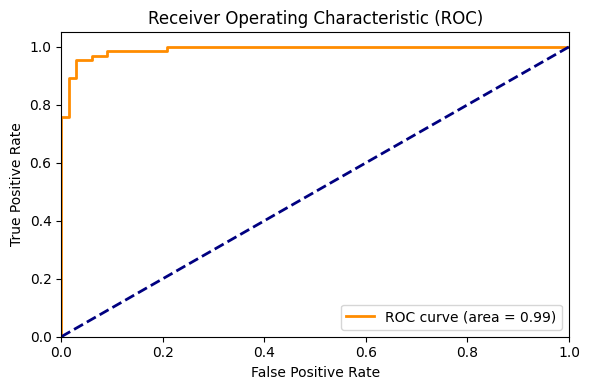

In [4]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Load Features
base_path = r""
X_time = np.load(os.path.join(base_path, r"C:\Users\hari7\Documents\Semester 3\Projects\Deception detection\Features\time_features.npy"))
X_freq = np.load(os.path.join(base_path, r"C:\Users\hari7\Documents\Semester 3\Projects\Deception detection\Features\freq_features.npy"))
y = np.load(os.path.join(base_path, r"C:\Users\hari7\Documents\Semester 3\Projects\Deception detection\Features\labels.npy"))

# Combine and Normalize
X = np.concatenate([X_time, X_freq], axis=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# tSNE Visualization of features before sequencing
print("Generating t-SNE plot. This may take a moment depending on dataset size.")
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="viridis", alpha=0.7)
plt.title("t-SNE Visualization of Extracted EEG Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Class (Truth/Deception)")
plt.tight_layout()
plt.show()

# Reshape to LSTM Format
SEQ_LEN = 5
num_samples = len(X) - SEQ_LEN + 1

X_seq = []
y_seq = []

for i in range(num_samples):
    seq = X[i:i+SEQ_LEN]
    label = y[i+SEQ_LEN-1]
    X_seq.append(seq)
    y_seq.append(label)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("LSTM input shape:", X_seq.shape)

# Train Test Validation Split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# PyTorch LSTM Model
class DeceptionLSTM(nn.Module):
    def __init__(self, input_dim):
        super(DeceptionLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout1(out)
        out = self.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out

input_dim = X_seq.shape[2]
model = DeceptionLSTM(input_dim)

# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 15
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    batch_losses = []
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
        val_losses.append(val_loss)
        
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Evaluate Model
model.eval()
with torch.no_grad():
    test_outputs_raw = model(X_test_t)
    test_outputs_prob = torch.sigmoid(test_outputs_raw).numpy().flatten()
    y_pred_class = (test_outputs_prob > 0.5).astype(int)
    y_test_numpy = y_test_t.numpy().flatten()

print("\nAccuracy:", accuracy_score(y_test_numpy, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_numpy, y_pred_class))

# Visualizations

# 1. Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_numpy, y_pred_class), annot=True, fmt='d', cmap='Purples')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 2. Loss Curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_numpy, test_outputs_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()